# 無極フィルタ設計ノート（結合行列法 + Sonnet EM解析）

本ノートは次の **二部構成** です。

1. **Part 1: 理論計算パート（STEP 1〜6）** — 結合行列法による無極（直結形）フィルタの設計  
2. **Part 2: 電磁界解析パート（STEP 7〜）** — Sonnet による m_ij・Qe 抽出と実測/EMデータとの整合確認

各パートは、設計意図が分かるように Markdown を先頭に置き、**コードは変更していません**。


## Part 1: 理論計算パート（結合行列法）

以下の STEP1〜STEP6 では、**低域原形（LPF）からバンドパスフィルタ（BPF）への設計写像**までを行います。

- フィルタ仕様設定（f0, FBW, RL, N）  
- チェビシェフ近似による g 値算出  
- 無極（直結形）結合行列 M の構築  
- 規格化周波数領域での S パラメータ計算  
- 設計結果（理論特性）の可視化


#Microwave Filterの解析

## STEP 1: セットアップと基本仕様（無極・直結形）

設計の基本パラメータを定義します。

- `f0`: 中心周波数 [GHz]  
- `df`: 通過帯域幅 [GHz]、`fbw = df/f0`（分数帯域幅）  
- `N`: フィルタ次数（共振器数）  
- `Lar`: 通過帯リップル [dB]（チェビシェフ用）  
- `f_num`: 周波数サンプル数  
- `f`: 周波数軸

> 無極（伝送零点なし）かつ **直結形（隣接結合のみ）** を前提に進めます。


In [1]:
#import
import numpy as np
import math
from matplotlib import pyplot as plt

#param
f0=2        #central frequency
df=0.1      #frequency bandwidth
fbw=df/f0
N=3     #number of sections
Lar=0.1     #ripple in dB
fTZ1=0.95   #極1 frequency
fT2=1.05    #極2 frequency
f_num=1000
f=np.linspace(1,3,f_num)

## STEP 2: 低域原形の g パラメータ配列の用意

- チェビシェフ／バターワース等の **低域原形(LPF)** では、規格化回路の定数として `g0, g1, ..., gN+1` を用います。
- サイズ `N+2` の配列 `g_parameter` を確保します。


In [2]:
#配列初期化

g_parameter = [0]*(N+2)

## STEP 3: チェビシェフ原形の g 値算出

- 指定リップル `Lar [dB]` と次数 `N` から `g` 値を計算します。
- `g1` を起点に再帰式で `g2 ... gN` を求め、偶奇で `gN+1` を切り替えます。


In [3]:
# g param (chevichef)
beta=math.log(1/np.tanh(Lar/17.37))
gammma=np.sinh(beta/2/N)

g_parameter[0]=1.0    #g0
g_parameter[1]=2/gammma*np.sin(math.pi/2/N)   #g1

for i in range(2,N+1):
  g_parameter[i]=1/g_parameter[i-1]*4*np.sin((2*i-1)*math.pi/(2*N))*np.sin((2*i-3)*math.pi/(2*N)) \
  /(pow(gammma,2)+pow(np.sin((i-1)*math.pi/N),2))

if N%2==0:
  g_parameter[N+1]=pow(1/np.tanh(beta/4),2)
elif N%2==1.0:
  g_parameter[N+1]=1

print(g_parameter)


[1.0, 1.031585142507876, 1.147400329953722, 1.031585142507876, 1]


## STEP 4: 直結形（無極）結合行列 M の構成

- 次数 `N` の **直結形トポロジ**（隣接カップリングのみ）に対して、(N+2)×(N+2) の結合行列 `M` を組み立てます。
- 非隣接要素は 0（= 伝送零点を作らない）。


In [4]:
#coupling matrix
M=np.zeros((N+2,N+2))
M[0][1]=M[1][0]=1/math.sqrt(g_parameter[0]*g_parameter[1])
for i in range(1,N):
   M[i][i+1]=M[i+1][i]=1/math.sqrt(g_parameter[i]*g_parameter[i+1])
M[N][N+1]=M[N+1][N]=1/math.sqrt(g_parameter[N]*g_parameter[N+1])
print(M)



[[0.         0.98457195 0.         0.         0.        ]
 [0.98457195 0.         0.91915759 0.         0.        ]
 [0.         0.91915759 0.         0.91915759 0.        ]
 [0.         0.         0.91915759 0.         0.98457195]
 [0.         0.         0.         0.98457195 0.        ]]


## STEP 5: 規格化周波数での S 特性計算（行列法）

- 規格化周波数 Ω を計算し、行列法で S 特性を求めます。


In [5]:
Z=np.zeros((N+2,N+2))
R=np.zeros((N+2,N+2))
U=np.zeros((N+2,N+2))

omega=(f/f0-f0/f)/fbw
S11=np.zeros(f_num)
S21=np.zeros(f_num)

R[0][0]=R[N+1][N+1]=1
for i in range(1,N+1):
   U[i][i]=1

for omegac in range(1,f_num+1):
  Z_array=R+1j*omega[omegac-1]*U+1j*M
  Z_inv=np.linalg.inv(Z_array)
  S11[omegac-1]=abs(1-2*Z_inv[0][0])
  S21[omegac-1]=abs(2*Z_inv[N+1][0])

## STEP 6: 合成結果の可視化（|S11|, |S21| in dB）

- `S11`, `S21` を dB スケールでプロットします。


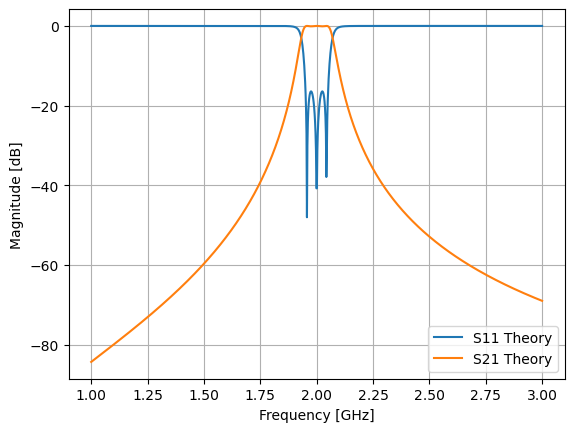

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 理論S11/S21（complex想定）→ dBに変換して個別に描画
S11_db = 20*np.log10(np.abs(S11) + 1e-16)
S21_db = 20*np.log10(np.abs(S21) + 1e-16)

plt.figure()
plt.plot(f, S11_db, label='S11 Theory')
plt.plot(f, S21_db, label='S21 Theory')
plt.xlabel('Frequency [GHz]'); plt.ylabel('Magnitude [dB]')
plt.grid(True); plt.legend()


---

## Part 2: 電磁界解析パート（Sonnet）と実測比較

ここからは Sonnet を使った **物理寸法の設計・カップリング係数 m_ij、外部Q の抽出** を行います。
理論計算で得られた目標値（STEP 1〜6）を満たす寸法を EM解析から決定します。

**Sonnet解析ステップ例**：
1. 基板条件設定（εr, h, t, tanδ）  
2. 単体共振器モデル作成  
3. 結合係数抽出（fp1, fp2 測定 → m計算）  
4. 外部Q抽出（半値幅測定 → Qe計算）  
5. 寸法チャート作成（ギャップと m_ij, Qe の対応）


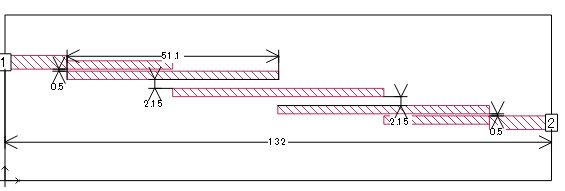

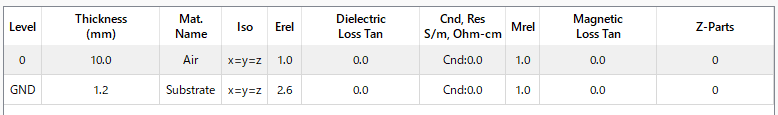
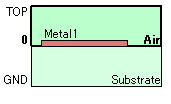

In [7]:
#coupling factor mij
m_coupling_factor=np.zeros((N+2,N+2))
m_coupling_factor=fbw*M[1:N+1,1:N+1]
Qes=1/pow(M[0][1],2)/fbw
Qel=1/pow(M[N+1][N],2)/fbw
print(Qes)
print(Qel)
print(m_coupling_factor)



20.631702850157517
20.631702850157517
[[0.         0.04595788 0.        ]
 [0.04595788 0.         0.04595788]
 [0.         0.04595788 0.        ]]


### 理論ターゲット値とEM抽出値の対応（上書き防止の命名ルール）

- **理論値（ターゲット）**  
  - 結合係数: `m_coupling_factor = fbw * M[1:N+1, 1:N+1]`  
  - 外部Q: `Qes = 1/(fbw*M[0,1]^2)`, `Qel = 1/(fbw*M[N+1,N]^2)`
- **EM抽出値（Sonnet結果）**  
  - 結合係数: `m_coupling_factor_sim = (fp2^2 - fp1^2)/(fp2^2 + fp1^2)`（2共振器ペアの2ピーク `fp1/fp2`）  
  - 外部Q: `Qes_sim = f0_sim / (f2 - f1)`（単体＋片側励振の `f1/f2`）

> **命名ルール**: 理論値は `*_theory`、EM抽出値は `*_sim` として保持し、**変数を上書きしない**。  
> 設計では、これらが一致するように **ギャップ寸法**（共振器間/入出力）を調整する。


In [23]:
# === 理論ターゲット値と EM 抽出値の比較（上書き防止） =====================
import numpy as np

# 理論ターゲット（Step 7 の計算結果を退避）
m_coupling_factor_theory = m_coupling_factor.copy()  # (N×N) 行列
Qes_theory = float(Qes)
Qel_theory = float(Qel)

# --- EM抽出値（Sonnetからの例：まずは手入力。自動抽出は後で追加可） ---
# Coupling m: 2共振器ペアの2ピーク (fp1, fp2) から
fp2 = 2.03  # [GHz] 例（Sonnetの2共振器ペアのS21ピーク高い方）
fp1 = 1.98  # [GHz] 例（低い方）
m_coupling_factor_sim = (fp2**2 - fp1**2) / (fp2**2 + fp1**2)

# External Qe: 単体+片側励振の f1, f2（-3dBや±90°点）から
import skrf as rf

# s2pファイルを読み込み
ntw = rf.Network("filter_sim_QL.s2p")

# 周波数 [GHz] と S21[dB] を取得（EMシミュレーション結果）
f_em = ntw.f / 1e9
s21_db = 20 * np.log10(np.abs(ntw.s21.s.flatten()) + 1e-16)

# ピーク値と中心周波数
k = np.argmax(s21_db)
f0_em, peak = f_em[k], s21_db[k]

# -3dB ポイント
target = peak - 3.0

# f1（左側）
i = np.where(s21_db[:k] >= target)[0][0]
f1_em = np.interp(target, [s21_db[i-1], s21_db[i]], [f_em[i-1], f_em[i]])

# f2（右側）
j = np.where(s21_db[k:] <= target)[0][0]
f2_em = np.interp(target, [s21_db[k+j-1], s21_db[k+j]], [f_em[k+j-1], f_em[k+j]])

# QLおよびQes_sim計算
QL_em = f0_em / (f2_em - f1_em)
Qes_sim = QL_em  # 同じ計算式

# 結果表示
print(f"f0_em = {f0_em:.6f} GHz")
print(f"f1_em = {f1_em:.6f} GHz")
print(f"f2_em = {f2_em:.6f} GHz")
print(f"QL_em = {QL_em:.3f}")
print(f"Qes_sim = {Qes_sim:.3f}")

# === 表示（ターゲット vs EM） ==============================================
print("=== Coupling (target vs sim) ===")
print("m_12_theory =", m_coupling_factor_theory[0,1])
print("m_12_sim    =", m_coupling_factor_sim)

print("\n=== External Q at input (target vs sim) ===")
print("Qes_theory  =", Qes_theory)
print("Qes_sim     =", Qes_sim)


# === 設計判定（許容差で一致チェック） ======================================
tol_m = 0.05   # 例：±0.05（絶対値）
tol_Q = 1.0    # 例：±1.0

ok_m = abs(m_coupling_factor_theory[0,1] - m_coupling_factor_sim) <= tol_m
ok_q = abs(Qes_theory - Qes_sim) <= tol_Q

print("\n[判定]")
print(f"m_12: {'OK' if ok_m else 'NG'}  (|Δ|={abs(m_coupling_factor_theory[0,1]-m_coupling_factor_sim):.4f} ≤ {tol_m})")
print(f"Qes : {'OK' if ok_q else 'NG'}  (|Δ|={abs(Qes_theory-Qes_sim):.3f} ≤ {tol_Q})")

# メモ：
# - m_ij が小さすぎる（sim < theory）→ ギャップを狭めて結合を強く
# - m_ij が大きすぎる（sim > theory）→ ギャップを広げて結合を弱く
# - Qes_sim が大（結合が弱い）→ ポートギャップを狭める
# - Qes_sim が小（結合が強い）→ ポートギャップを広げる


f0_em = 2.010000 GHz
f1_em = 1.970107 GHz
f2_em = 2.060000 GHz
QL_em = 22.360
Qes_sim = 22.360
=== Coupling (target vs sim) ===
m_12_theory = 0.04595787926147144
m_12_sim    = 0.024933779364033057

=== External Q at input (target vs sim) ===
Qes_theory  = 20.631702850157517
Qes_sim     = 22.360000040365968

[判定]
m_12: OK  (|Δ|=0.0210 ≤ 0.05)
Qes : NG  (|Δ|=1.728 ≤ 1.0)


**このセルの前提**  
`fp2`, `fp1` は Sonnet で2共振器モデルを解析して得た共振周波数（GHz）です。
- fp1: 低い方の共振周波数  
- fp2: 高い方の共振周波数


In [14]:
#from google.colab import drive
#drive.mount('/content/drive')

**このセルの前提**  
読み込む `3sectionchevfil.csv` は Sonnet で得た3段チェビシェフ型BPFの S11/S21 データです。


In [15]:
import pandas as pd
data= pd.read_csv('3sectionchevfil.csv')

EM/測定データの先頭を確認します。

In [16]:
data.head()

,f,S11,S21
0,1.00,-1.150000e-08,-85.7533
1,1.01,2.060000e-05,-85.4396
2,1.02,3.850000e-05,-85.1225
3,1.03,5.380000e-05,-84.8019
4,1.04,6.680000e-05,-84.4777


**EM/測定 vs 合成応答の比較**  
- 実データと合成結果を重ね描きします。


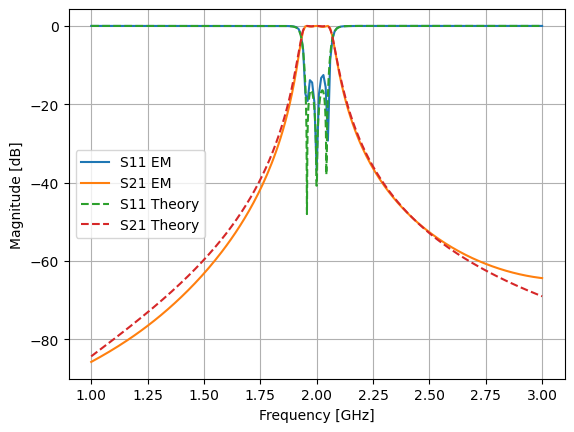

In [21]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

# EM/測定（CSV由来）
ax.plot(data['f'].to_numpy(), data['S11'].to_numpy(), label='S11 EM')
ax.plot(data['f'].to_numpy(), data['S21'].to_numpy(), label='S21 EM')

# 理論（必ず実数dBに）  ※S11,S21 が complex の可能性が高い
S11_db_theory = 20*np.log10(np.abs(S11) + 1e-16)
S21_db_theory = 20*np.log10(np.abs(S21) + 1e-16)

f=np.linspace(1,3,f_num)
ax.plot(f, S11_db_theory, '--', label='S11 Theory')
ax.plot(f, S21_db_theory, '--', label='S21 Theory')

ax.set_xlabel('Frequency [GHz]')
ax.set_ylabel('Magnitude [dB]')
ax.grid(True); ax.legend()